# Setup & Imports

In [17]:
# %pip install -r ../requirements.txt

In [6]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "src"))

import pandas as pd
from data_loader import load_raw_data
from features import build_features
from model import build_model, metrics
from interpret import plot_forecast, shap_summary

OUTPUT_DIR = os.path.join(os.getcwd(), "..", "outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

import warnings
warnings.filterwarnings('ignore')

# Load Data

In [7]:
df_raw = load_raw_data("../data")
df_raw.head()

Raw rows: 248592


,REGION,SETTLEMENTDATE,TOTALDEMAND,RRP,PERIODTYPE
0,NSW1,2022/05/01 00:05:00,6973.88,299.99,TRADE
1,NSW1,2022/05/01 00:10:00,7025.21,299.98,TRADE
2,NSW1,2022/05/01 00:15:00,6998.04,299.98,TRADE
3,NSW1,2022/05/01 00:20:00,6890.58,299.98,TRADE
4,NSW1,2022/05/01 00:25:00,6870.36,299.98,TRADE


# Feature Engineering

In [8]:
df, dp = build_features(df_raw)
df.head()

,TOTALDEMAND,RRP,is_holiday,hour,weekday,month,hour_sin,hour_cos,month_sin,month_cos,...,"dp_sin(2,freq=D)","dp_cos(2,freq=D)","dp_sin(3,freq=D)","dp_cos(3,freq=D)","dp_sin(4,freq=D)","dp_cos(4,freq=D)","dp_sin(1,freq=YE-DEC)","dp_cos(1,freq=YE-DEC)","dp_sin(2,freq=YE-DEC)","dp_cos(2,freq=YE-DEC)"
SETTLEMENTDATE,,,,,,,,,,,,,,,,,,,,,
2018-01-08 00:30:00,7641.48,75.58,0,0,0,1,0.000000,1.000000,0.0,1.0,...,0.258819,0.965926,0.382683,9.238795e-01,0.500000,8.660254e-01,0.120564,0.992706,0.239369,0.970929
2018-01-08 01:00:00,7367.35,75.68,0,1,0,1,0.258819,0.965926,0.0,1.0,...,0.500000,0.866025,0.707107,7.071068e-01,0.866025,5.000000e-01,0.120920,0.992662,0.240066,0.970757
2018-01-08 01:30:00,7000.75,56.93,0,1,0,1,0.258819,0.965926,0.0,1.0,...,0.707107,0.707107,0.923880,3.826834e-01,1.000000,6.123234e-17,0.121276,0.992619,0.240762,0.970584
2018-01-08 02:00:00,6796.19,54.78,0,2,0,1,0.500000,0.866025,0.0,1.0,...,0.866025,0.500000,1.000000,6.123234e-17,0.866025,-5.000000e-01,0.121632,0.992575,0.241458,0.970411
2018-01-08 02:30:00,6757.94,54.68,0,2,0,1,0.500000,0.866025,0.0,1.0,...,0.965926,0.258819,0.923880,-3.826834e-01,0.500000,-8.660254e-01,0.121988,0.992532,0.242154,0.970238


# Train / Valid / Test Split

In [9]:
FEATURE_LR   = [c for c in df.columns if c.startswith("dp_")] + ["is_holiday"]
FEATURE_TREE = ["lag_1","lag_2","lag_48","lag_336","rolling_48","rolling_336",
                "hour_sin","hour_cos","month_sin","month_cos",
                "hour_day_interaction","is_holiday","RRP"]
TARGET = "TOTALDEMAND"

n = len(df)
train_end = int(n * 0.70)
valid_end  = int(n * 0.90)

train = df.iloc[:train_end]
valid = df.iloc[train_end:valid_end]
test  = df.iloc[valid_end:]

X1_train, y_train = train[FEATURE_LR],   train[TARGET]
X1_valid, y_valid = valid[FEATURE_LR],   valid[TARGET]
X1_test,  y_test  = test[FEATURE_LR],    test[TARGET]
X2_train = train[FEATURE_TREE]
X2_valid = valid[FEATURE_TREE]
X2_test  = test[FEATURE_TREE]

print(f"Train: {len(train):,} | Valid: {len(valid):,} | Test: {len(test):,}")

Train: 67,099 | Valid: 19,171 | Test: 9,586


# Train

In [10]:
model = build_model()
model.fit(X1_train, X2_train, y_train,
          X1_valid=X1_valid, X2_valid=X2_valid, y_valid=y_valid)
print("Model trained!")

Model trained!


# Evaluate

In [11]:
print('Train:', metrics(y_train, model.predict(X1_train, X2_train)))
print('Valid:', metrics(y_valid, model.predict(X1_valid, X2_valid)))
print('Test: ', metrics(y_test,  model.predict(X1_test,  X2_test)))

Train: {'RMSE': np.float64(156.26983), 'MAE': 121.69766, 'R2': 0.98439}
Valid: {'RMSE': np.float64(336.01779), 'MAE': 275.27817, 'R2': 0.93032}
Test:  {'RMSE': np.float64(483.79397), 'MAE': 425.36486, 'R2': 0.85244}


# Save Predictions

In [14]:
y_pred_test = model.predict(X1_test, X2_test)
preds_df = pd.DataFrame({"actual": y_test, "predicted": y_pred_test})
display(preds_df.head())

preds_path = os.path.join(OUTPUT_DIR, "test_predictions.csv")
preds_df.to_csv(preds_path)
print(f"Predictions saved → {preds_path}")

,actual,predicted
SETTLEMENTDATE,,
2022-12-10 07:30:00,6235.831667,6216.244307
2022-12-10 08:00:00,6053.511667,6020.523373
2022-12-10 08:30:00,5913.445000,5891.505106
2022-12-10 09:00:00,5948.463333,5794.406587
2022-12-10 09:30:00,5895.945000,5581.033674


Predictions saved → /home/lh44/my_folder/projects/electricity-demand-forecasting-nsw/tutorials/../outputs/test_predictions.csv


# Forecast Plot

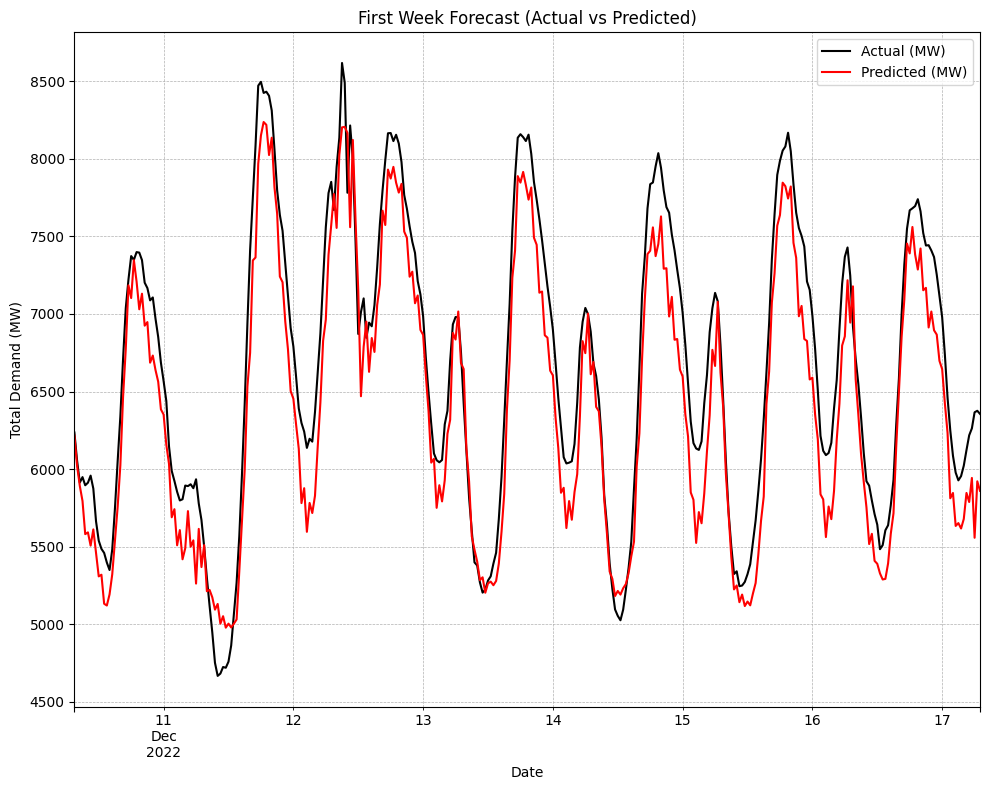

Forecast plot saved → /home/lh44/my_folder/projects/electricity-demand-forecasting-nsw/tutorials/../outputs/forecast.png


In [15]:
forecast_path = os.path.join(OUTPUT_DIR, "forecast.png")
plot_forecast(y_test, y_pred_test)
plot_forecast(y_test, y_pred_test, save_path=forecast_path)
print(f"Forecast plot saved → {forecast_path}")

# SHAP

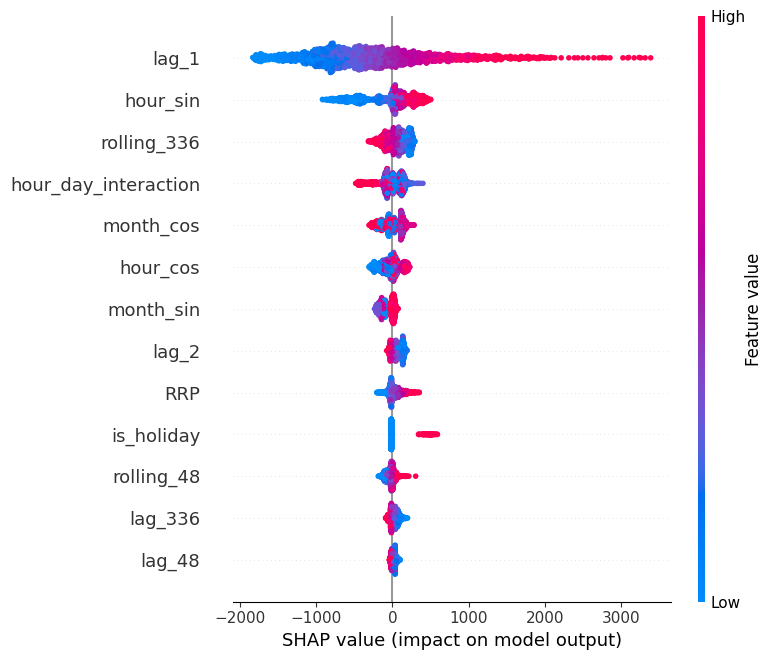

SHAP plot saved → /home/lh44/my_folder/projects/electricity-demand-forecasting-nsw/tutorials/../outputs/shap_summary.png


In [16]:
shap_path = os.path.join(OUTPUT_DIR, "shap_summary.png")
shap_summary(model, X2_test)
shap_summary(model, X2_test, save_path=shap_path)
print(f"SHAP plot saved → {shap_path}")